# PPSTM Constant current tutorial

This notebook give a quick overview on how to compute constant current images with PPSTM. It assumes that you already calculated the constant height images with PPSTM (fixed tip with s wave usually).

Author: Lauri Kurki

Any questions can be posted on the PPSTM Github issues section or directly to lauri.1.kurki@aalto.fi (or adam.foster@aalto.fi).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

from typing import Optional

## Data loading + visualization

In [2]:
d = np.load("STM_0.1_tip_fixed-s_WF_5.0_WF_decay_0.5_eta_0.1.npz", allow_pickle=True)
print(d)

# z has to be last dimension
data = d['data'].transpose(1, 2, 0)
print(f"Shape of the data: {data.shape}")

NpzFile 'STM_0.1_tip_fixed-s_WF_5.0_WF_decay_0.5_eta_0.1.npz' with keys: data, lvec, atoms, lvec0
Shape of the data: (201, 201, 41)


The npz file contains a stack of constant height images taken at 0.1 Å intervals. Below we visualize the whole stack. First image is closest and the  last image is furthest.

NOTE: This was done with a fixed tip setting so the difference is small visually, but if you look at the colorbar, the closest image has 4 orders of magnitude larger values.

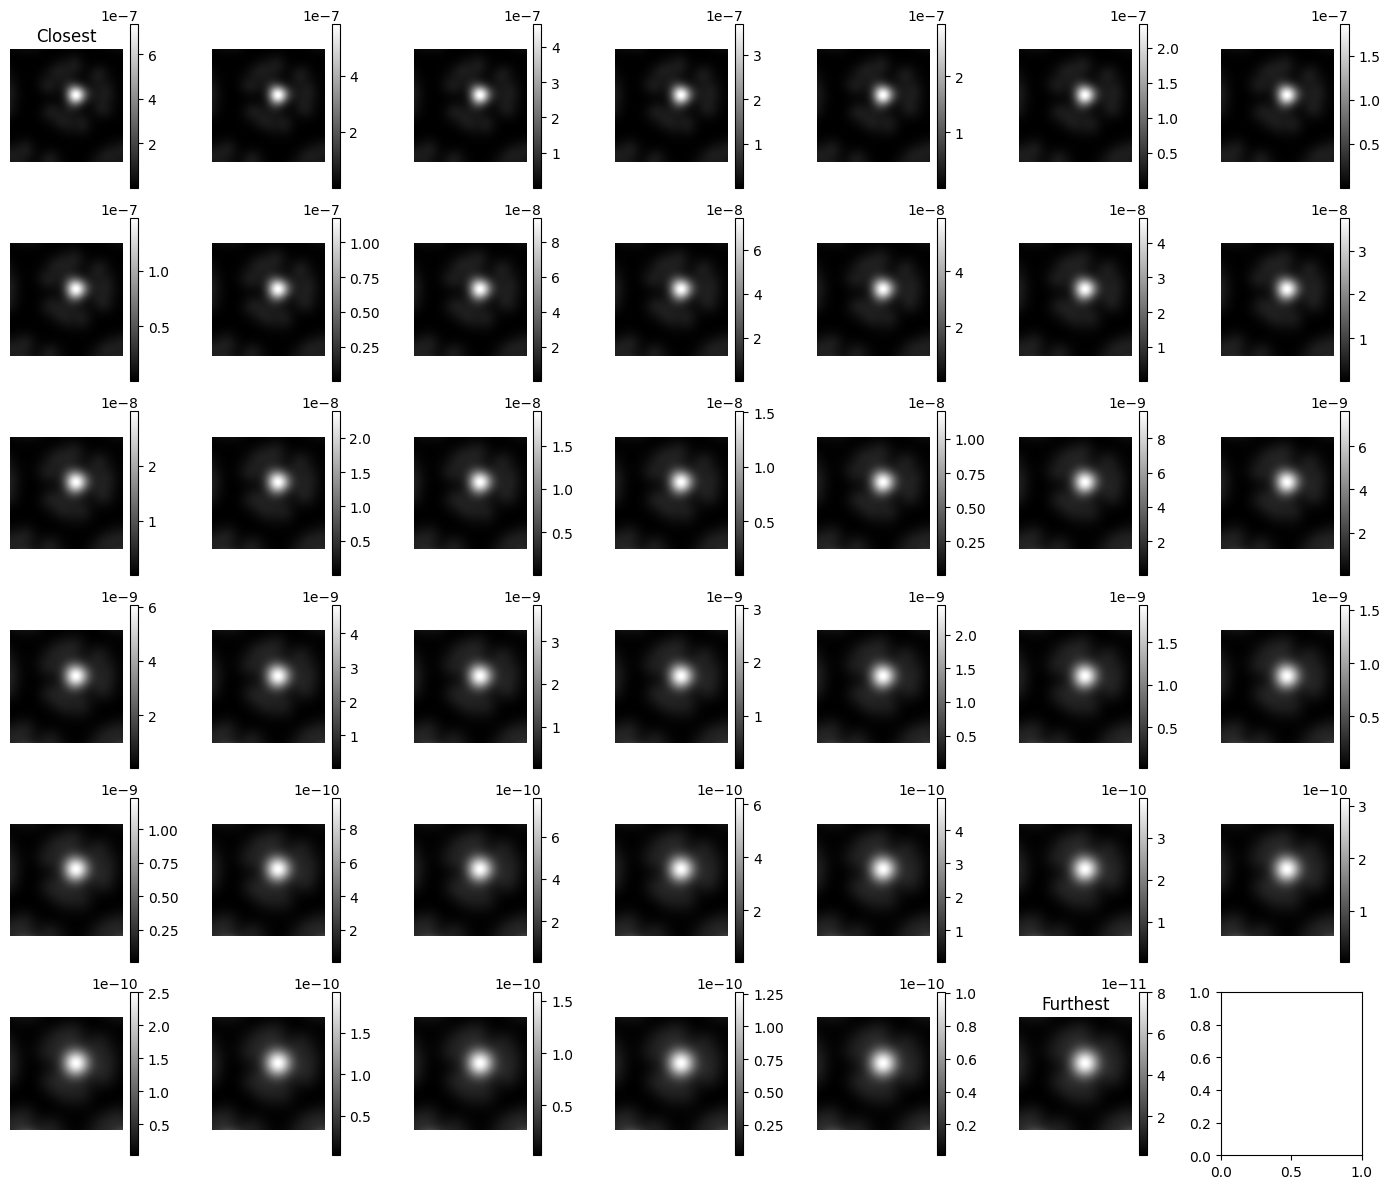

In [3]:
ncols = 7
nrows = data.shape[-1] // ncols + 1
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))

for i in range(data.shape[-1]):
    ax = axs.flatten()[i]
    im = ax.imshow(data[..., i], cmap='gray')
    plt.colorbar(im, ax=ax)
    ax.axis('off')

axs.flatten()[0].set_title("Closest")
axs.flatten()[-2].set_title("Furthest")

plt.tight_layout()

## Constant current

In [4]:
def compute_constant_current_stm(
    array: np.ndarray,
    current_setpoint: float,
    zs: np.ndarray,
    interp_order: Optional[int] = 1,
    power_parameter: Optional[float] = 1.0,
    gaussian_factor: Optional[float] = None
) -> np.ndarray:
    """
    Compute the constant current STM image from the given data.

    Args:
        array (np.ndarray): constant height stm stack of shape (nx, ny, nz)
        current_setpoint (float): the setpoint value for the constant current STM
        zs (np.ndarray): the z values of the constant height stack
        interp_order (int): the number of nearest neighbors to interpolate
        power_parameter (float): the power parameter for the interpolation

    Returns:
        np.ndarray: the constant current STM image
    """
    # https://stackoverflow.com/questions/13627104/using-numpy-scipy-to-calculate-iso-surface-from-3d-array
    if interp_order < 1: interp_order = 1
    dist = (array - current_setpoint)**2
    arg = np.argsort(dist,axis=2)
    dist.sort(axis=2)
    w_total = 0.
    z = np.zeros(array.shape[:2], dtype=float)
    for i in range(int(interp_order)):
        zi = np.take(zs, arg[:,:,i])
        valuei = dist[:,:,i]
        wi = 1/valuei
        np.clip(wi, 0, 1.e6, out=wi) # avoiding overflows
        w_total += wi**power_parameter
        z += zi*wi**power_parameter
    z /= w_total
    if gaussian_factor is not None:
        z = gaussian_filter(z, gaussian_factor)
    return z

### Current setpoint

The constant current image is calculated from the stack of constant height images by computing the isosurface of the current setpoint. This is done with the function `compute_constant_current_stm`.

The most important parameter is the current setpoint. I've found that a good starting point is 10% of the maximum current but this can vary at least from 0.5 % to 30 % depending on the experiment. Let's visualize the effect for some current setpoints.

NOTE: Another very important factors that affect the image outside of the constant current calculation:
 - scan voltage
 - eta

Often you have to compute a bunch of constant height stacks with different voltages and etas and compare the results with the experimental images.

In [5]:
# Set the parameters
current_setpoints = [0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 0.99]
interp_order = 1
power_parameter = 1.0
zs = np.linspace(0, 4, data.shape[-1])

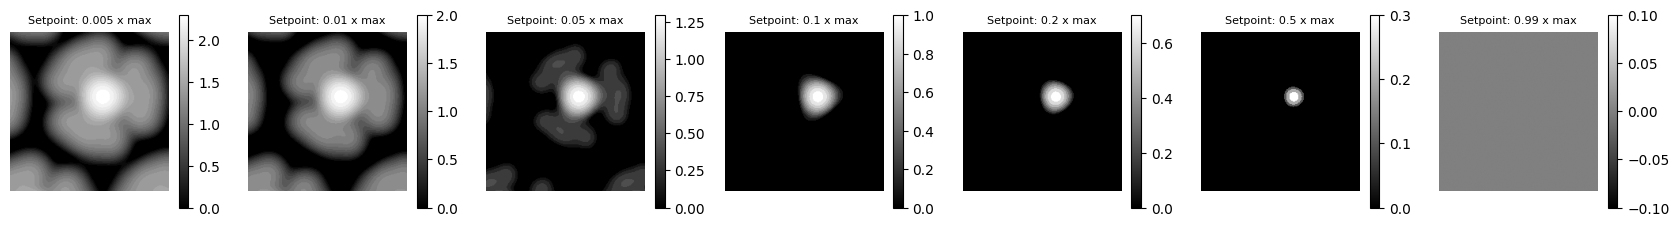

In [6]:
fig = plt.figure(figsize=(len(current_setpoints)*3, 2.5))
for i, current_setpoint in enumerate(current_setpoints):
    stm = compute_constant_current_stm(data, current_setpoint*data.max(), zs, interp_order=interp_order, power_parameter=power_parameter)
    ax = plt.subplot(1, len(current_setpoints), i+1)
    im = ax.imshow(stm, cmap='gray')
    plt.colorbar(im, ax=ax)
    ax.axis('off')
    ax.set_title(f"Setpoint: {current_setpoint} x max", fontdict={'fontsize': 8})

The colorbar represents the height, but probably the absolute values shouldn't be trusted as it hasn't been properly calibrated.

### Scanning height

You can also try different ranges for the scanning heights for example if you have accidentally scanned too close. A good habit is to compute the constant height stack with a large range and then tweak the range in the calculation.

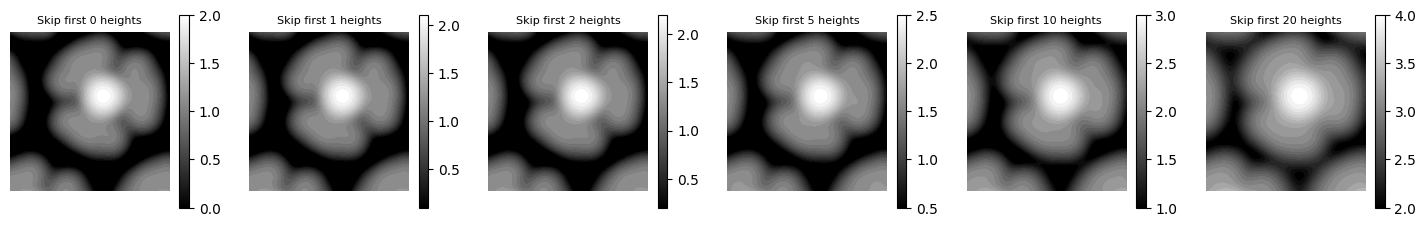

In [7]:
skip_first_N = [0, 1, 2, 5, 10, 20]
interp_order = 1
power_parameter = 1.0

fig = plt.figure(figsize=(len(skip_first_N)*3, 2.5))
for i, N in enumerate(skip_first_N):
    stm = compute_constant_current_stm(data[..., N:], 0.01*data[..., N:].max(), zs[N:], interp_order=interp_order, power_parameter=power_parameter)
    ax = plt.subplot(1, len(skip_first_N), i+1)
    im = ax.imshow(stm, cmap='gray')
    plt.colorbar(im, ax=ax)
    ax.axis('off')
    ax.set_title(f"Skip first {N} heights", fontdict={'fontsize': 8})

### Gaussian blurring

Especially with large currents and large scan intervals, the resulting constant current image might only have a few relevant heights which makes the image pixelated. For easier comparison with experimental images, gaussian blurring can be applied. Here's the effect for the setpoint 0.05 example which is slightly pixelated.

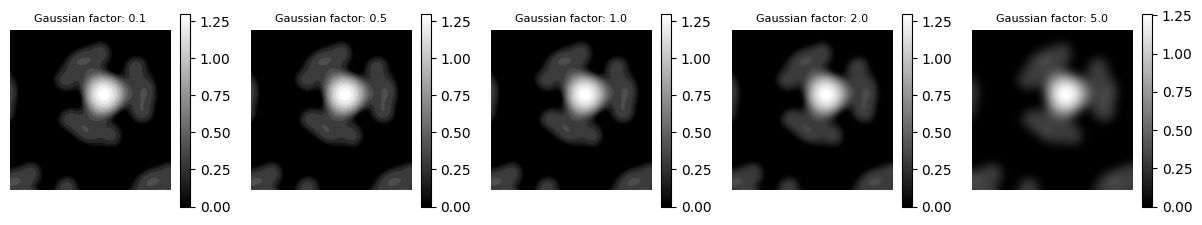

In [8]:
gaussian_factors = [0.1, 0.5, 1.0, 2.0, 5.0]
interp_order = 1
power_parameter = 1.0

fig = plt.figure(figsize=(len(gaussian_factors)*3, 2.5))
for i, gaussian_factor in enumerate(gaussian_factors):
    stm = compute_constant_current_stm(data, 0.05*data.max(), zs, interp_order=interp_order, power_parameter=power_parameter, gaussian_factor=gaussian_factor)
    ax = plt.subplot(1, len(gaussian_factors), i+1)
    im = ax.imshow(stm, cmap='gray')
    plt.colorbar(im, ax=ax)
    ax.axis('off')
    ax.set_title(f"Gaussian factor: {gaussian_factor}", fontdict={'fontsize': 8})

### Interpolation order

The interpolation order can also affect the image sometimes but I've found this and the power parameter to not have a big impact.

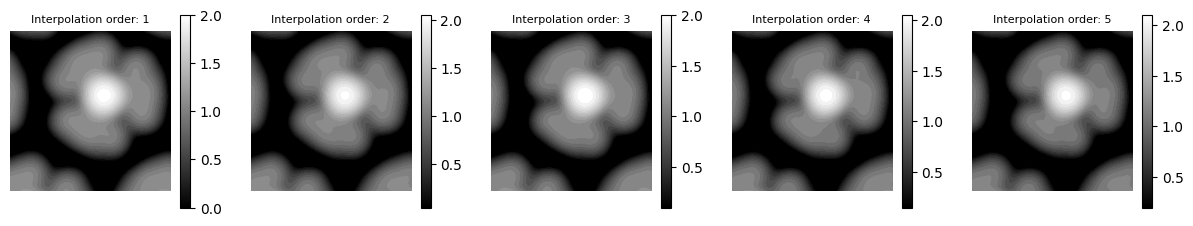

In [9]:
interpolation_orders = [1, 2, 3, 4, 5]
power_parameter = 1.0
gaussian_factor = None

fig = plt.figure(figsize=(len(interpolation_orders)*3, 2.5))
for i, interp_order in enumerate(interpolation_orders):
    stm = compute_constant_current_stm(data, 0.01*data.max(), zs, interp_order=interp_order, power_parameter=power_parameter, gaussian_factor=gaussian_factor)
    ax = plt.subplot(1, len(interpolation_orders), i+1)
    im = ax.imshow(stm, cmap='gray')
    plt.colorbar(im, ax=ax)
    ax.axis('off')
    ax.set_title(f"Interpolation order: {interp_order}", fontdict={'fontsize': 8})